# Bank Account Fraud Dataset Suite (NeurIPS 2022)

출처 - kaggle<br>
https://www.kaggle.com/datasets/sgpjesus/bank-account-fraud-dataset-neurips-2022?select=Base.csv

## 은행 사기계좌 판별
1. classification model
2. imbalanced data
3. 

In [1]:
import pandas as pd
import numpy as np

import missingno

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
raw = pd.read_csv('data/Base.csv')
raw.head(5)

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,...,0,1500.0,0,INTERNET,16.224843,linux,1,1,0,0
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,...,0,1500.0,0,INTERNET,3.363854,other,1,1,0,0
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,AB,1095,...,0,200.0,0,INTERNET,22.730559,windows,0,1,0,0
3,0,0.6,0.475100,11,14,30,0.006991,-1.863101,AB,3483,...,0,200.0,0,INTERNET,15.215816,linux,1,1,0,0
4,0,0.9,0.842307,-1,29,40,5.742626,47.152498,AA,2339,...,0,200.0,0,INTERNET,3.743048,other,0,1,0,0


In [3]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   fraud_bool                        1000000 non-null  int64  
 1   income                            1000000 non-null  float64
 2   name_email_similarity             1000000 non-null  float64
 3   prev_address_months_count         1000000 non-null  int64  
 4   current_address_months_count      1000000 non-null  int64  
 5   customer_age                      1000000 non-null  int64  
 6   days_since_request                1000000 non-null  float64
 7   intended_balcon_amount            1000000 non-null  float64
 8   payment_type                      1000000 non-null  object 
 9   zip_count_4w                      1000000 non-null  int64  
 10  velocity_6h                       1000000 non-null  float64
 11  velocity_24h                      1000

In [4]:
raw.shape

(1000000, 32)

In [5]:
df = raw.copy()

In [6]:
### Target variabel
df['fraud_bool'].value_counts()

fraud_bool
0    988971
1     11029
Name: count, dtype: int64

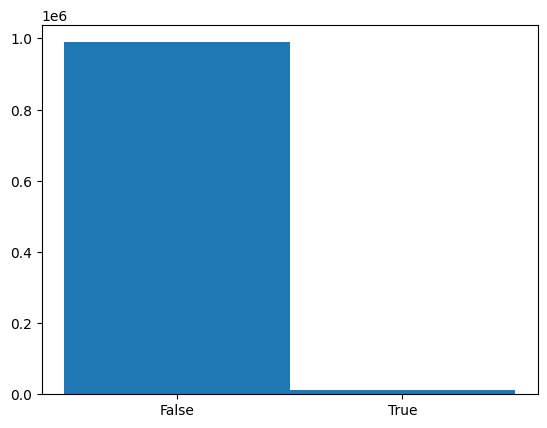

In [7]:
plt.hist(df['fraud_bool'], bins=2)
plt.xticks([0.25, 0.75], ['False', 'True'])
plt.show()

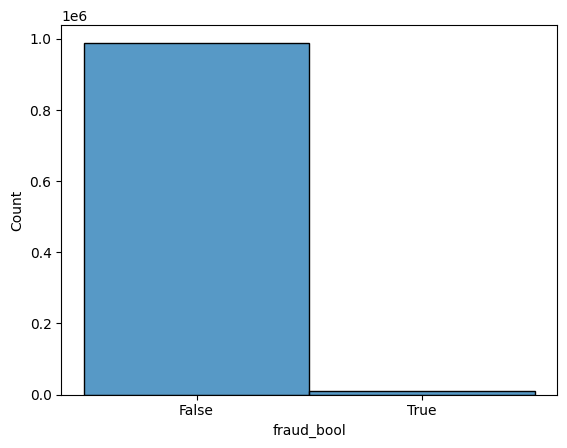

In [8]:
sns.histplot(df['fraud_bool'], bins=2)
plt.xticks([0.25, 0.75], ['False', 'True'])
plt.show()

In [9]:
### categorical / binary variable

categorical_val = ['fraud_bool', 'employment_status', 'email_is_free', 'housing_status', 'phone_home_valid', 'phone_mobile_valid',
                   'has_other_cards', 'foreign_request', 'device_os', 'keep_alive_session', 'device_distinct_emails_8w', 'device_fraud_count',
                   'payment_type', 'source']

df_category = df[categorical_val]
df_object = df_category.select_dtypes(include=['object'])
df_numeric = df.drop(columns=categorical_val)


In [10]:
df_numeric.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 18 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   income                            1000000 non-null  float64
 1   name_email_similarity             1000000 non-null  float64
 2   prev_address_months_count         1000000 non-null  int64  
 3   current_address_months_count      1000000 non-null  int64  
 4   customer_age                      1000000 non-null  int64  
 5   days_since_request                1000000 non-null  float64
 6   intended_balcon_amount            1000000 non-null  float64
 7   zip_count_4w                      1000000 non-null  int64  
 8   velocity_6h                       1000000 non-null  float64
 9   velocity_24h                      1000000 non-null  float64
 10  velocity_4w                       1000000 non-null  float64
 11  bank_branch_count_8w              1000

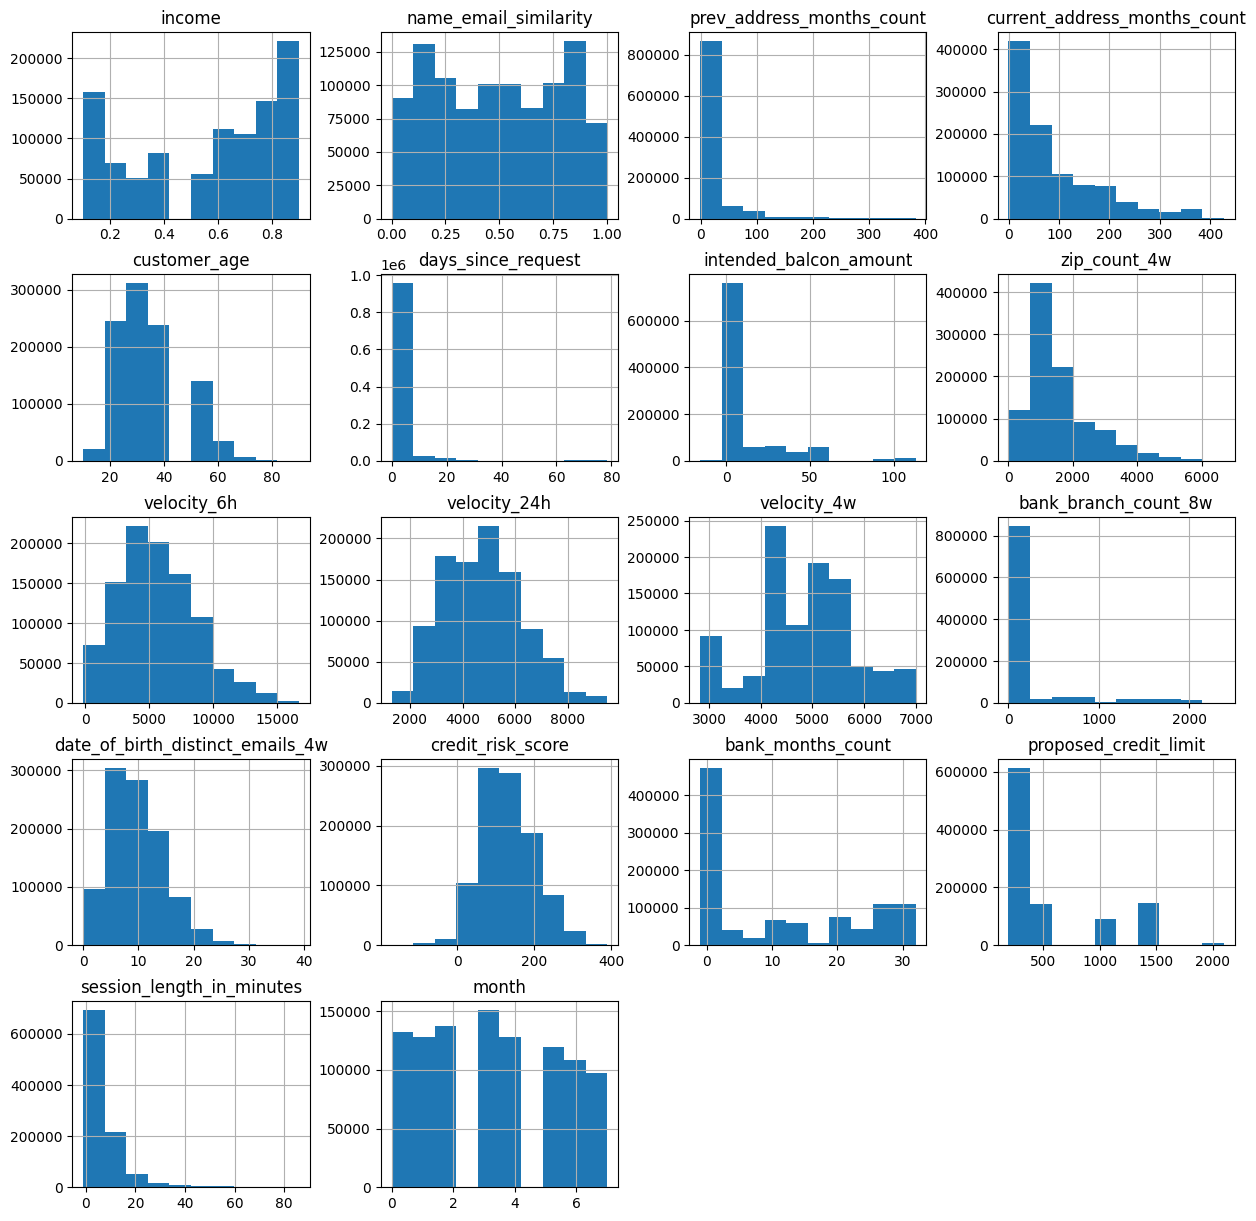

In [11]:
# numeric

plt.rc('axes', labelsize=14, titlesize=12)
plt.rc('legend', fontsize=14)

df_numeric.hist(figsize=(15, 15))
plt.savefig('image/numric.png')


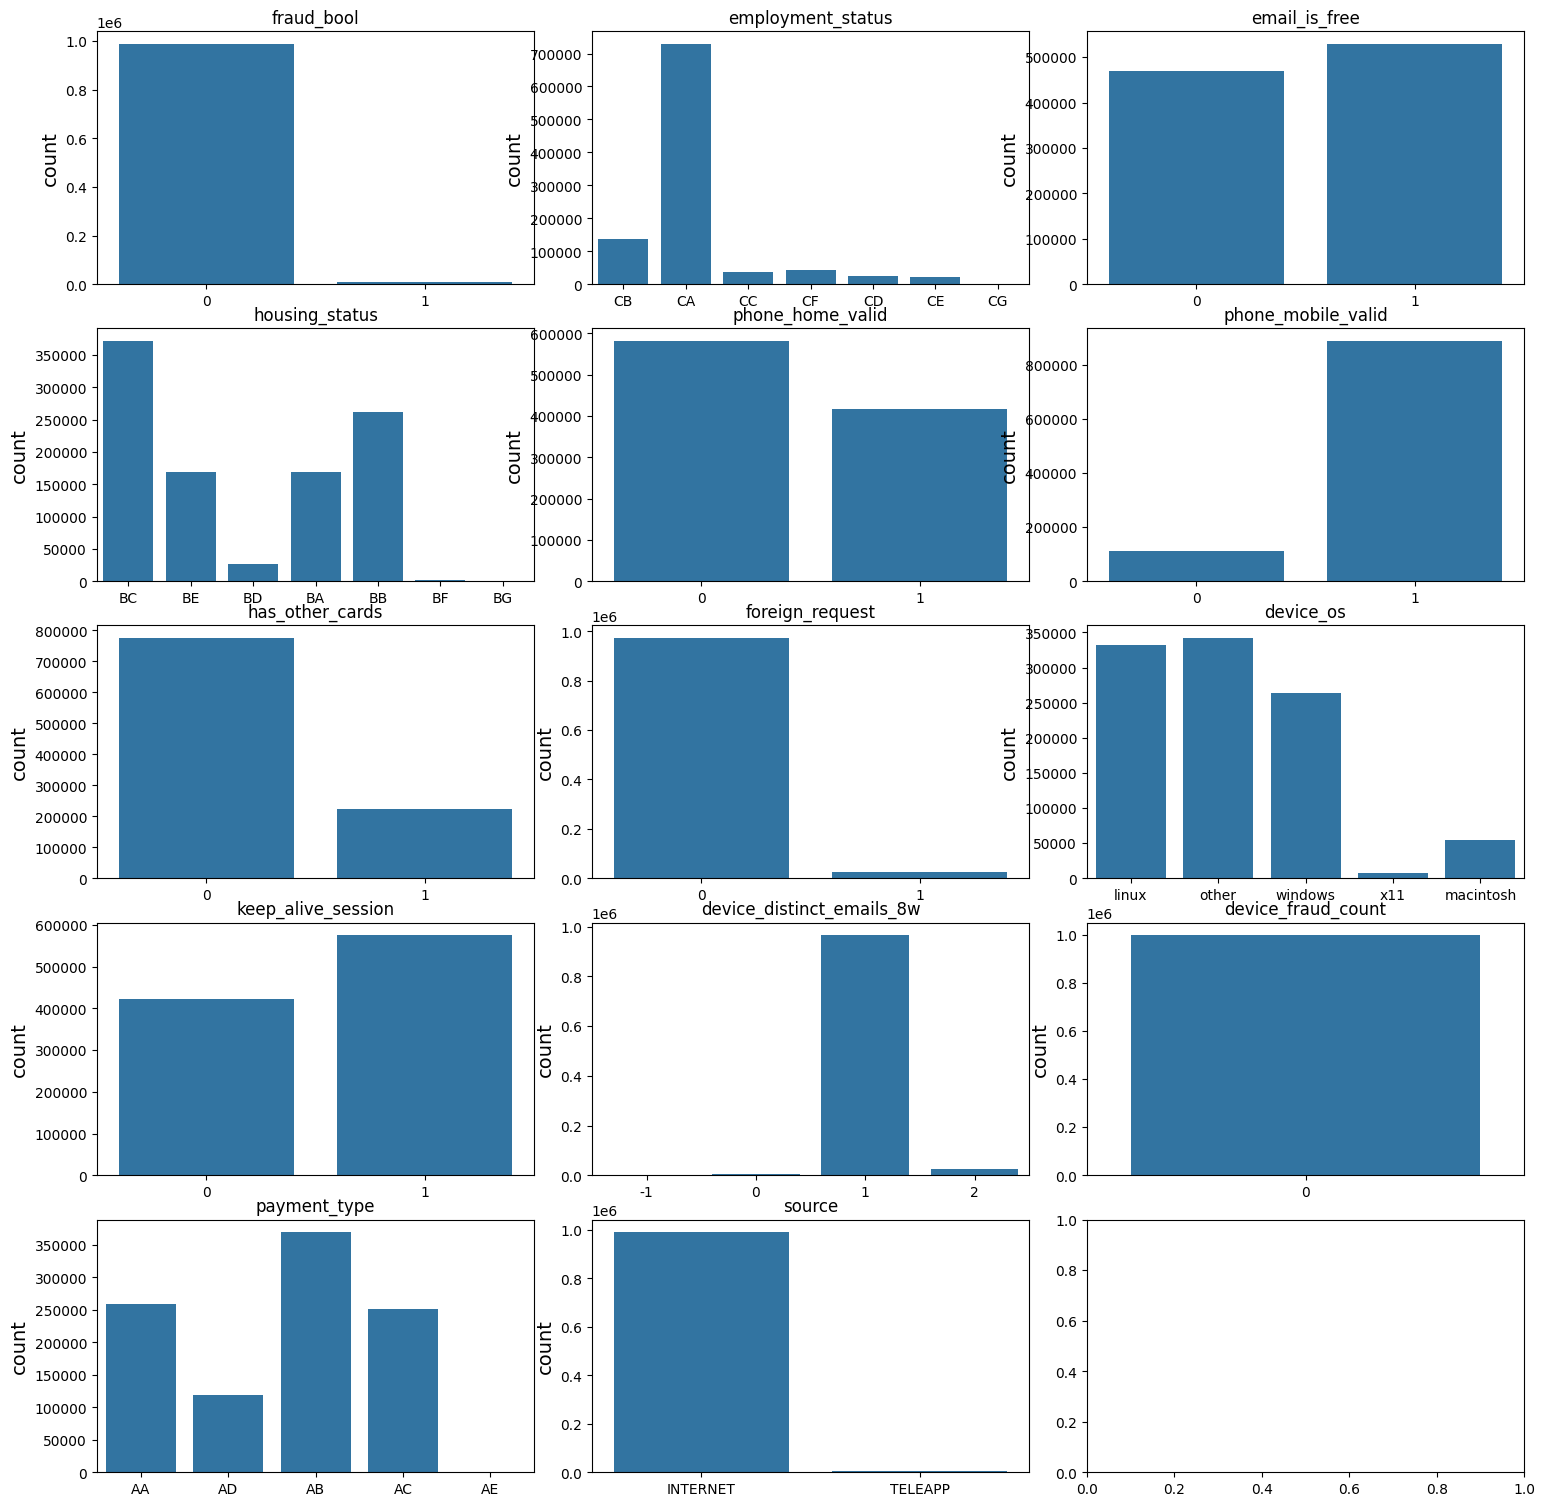

In [12]:
## non-numeric

f, axes = plt.subplots(5, 3, figsize=(15, 15))

# 플롯 간격 조정
plt.tight_layout()

# 각 열에 대해 countplot 그리기
for i, column in enumerate(df_category.columns):
    sns.countplot(data=df_category, x=column, ax=axes[i//3, i%3])
    axes[i//3, i%3].set_title(column)  # 각 subplot에 제목 설정
    axes[i//3, i%3].set_xlabel('')
plt.savefig('image/non_numric.png')


In [13]:
## 특수한 변수의 경우

df['device_fraud_count'].value_counts()
df.drop(columns='device_fraud_count', inplace= True)

## 모든 변수가 하나의 값?

# 결측치 missing value 

1. no na/null values in dataset

2. some feature has missing value 
    - prev_address_months_count -> -1 <br>
    - current_address_months_count -> -1 <br>
    - intended_balcon_amount -> negative value <br>
    - bank_months_count -> -1 <br>
    - session_length_in_minutes -> -1 <br>
    - device_distinct_emails -> -1 <br>


-> negative value is missing value in these feature

-> missing value to np.nan



In [14]:
# function to_nan
# negative value to np.nan

def to_nan(feature_list):
    for feature in feature_list:
        df[feature] = df[feature].apply(lambda x: x if x >= 0 else np.nan)

In [15]:
missing_features = ['prev_address_months_count', 'current_address_months_count', 'intended_balcon_amount', 'bank_months_count', 'session_length_in_minutes', 'device_distinct_emails_8w' ]
to_nan(missing_features)

In [16]:
df[missing_features].isna().sum()


prev_address_months_count       712920
current_address_months_count      4254
intended_balcon_amount          742523
bank_months_count               253635
session_length_in_minutes         2015
device_distinct_emails_8w          359
dtype: int64

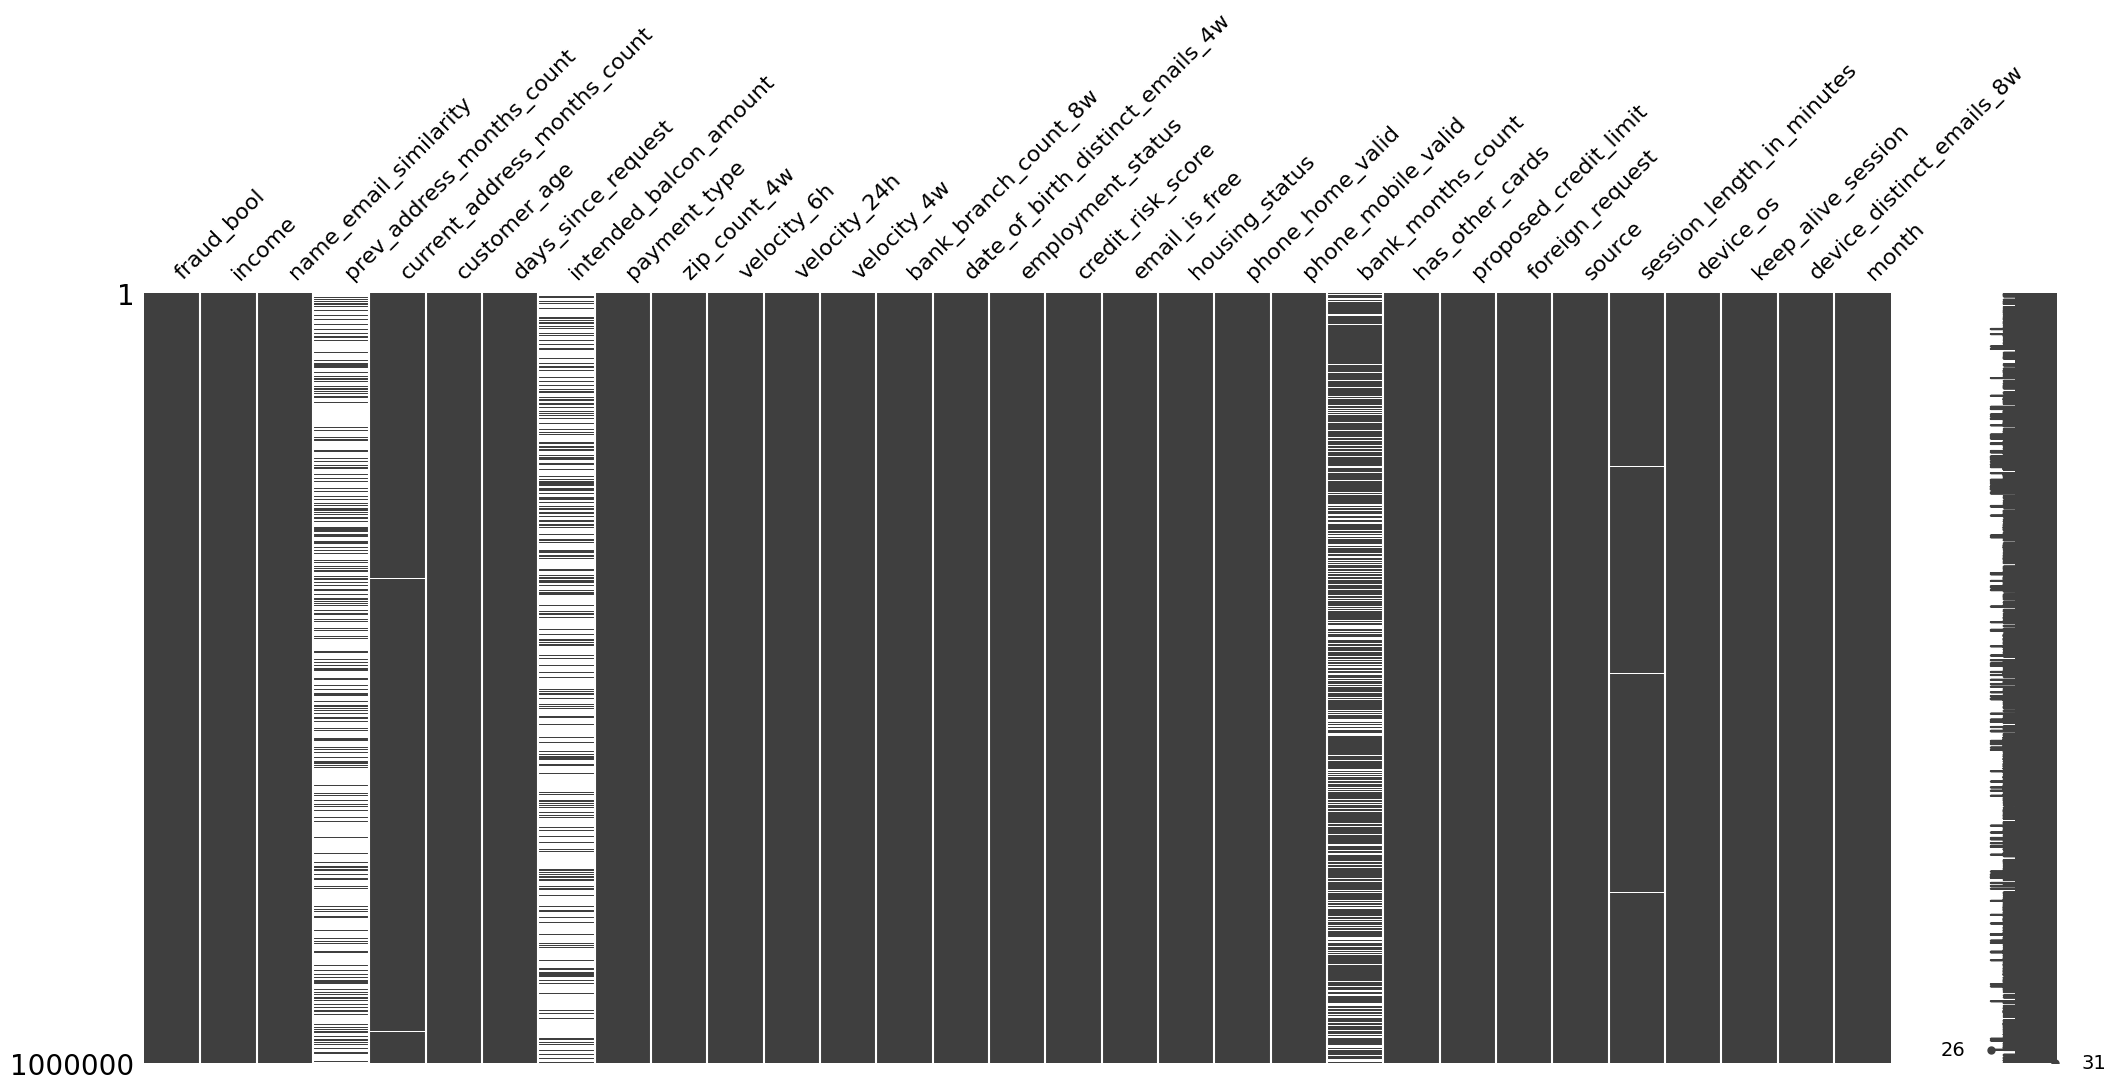

In [17]:
missingno.matrix(df)
plt.show()

## 결측치 처리

#### 1. 결측치 수
- prev_address_months_count  / 712920 <br>
-> drop
- current_address_months_count / 4254 <br>
-> na drop
- intended_balcon_amount      / 742523 <br>
-> drop
- bank_months_count           / 253635 <br>
-> imputaion
- session_length_in_minutes   / 2015 <br>
-> na drop
- device_distinct_emails_8w   / 359 <br>
-> na drop

#### 2. 결측치 처리 방법 - imputation
https://data-newbie.tistory.com/257

In [18]:
## feature drop - prev_address_months_count / intended_balcon_amount

df.drop(columns=['prev_address_months_count', 'intended_balcon_amount'], inplace= True)

In [19]:
## na drop - current_address_months_count / session_length_in_minutes / device_distinct_emails_8w

df.dropna(subset=['current_address_months_count', 'session_length_in_minutes', 'device_distinct_emails_8w'], inplace= True)


# 변수 특성 확인

### One-hot encoding

유형 변수들을 처리하는 방법

유형변수
- payment_type
- employment_status
- housing_status
- device_os

In [20]:
df['payment_type'].value_counts()

payment_type
AB    368115
AA    257573
AC    249692
AD    117938
AE       289
Name: count, dtype: int64

In [21]:
df['employment_status'].value_counts()

employment_status
CA    725305
CB    137624
CF     43838
CC     37506
CD     26305
CE     22579
CG       450
Name: count, dtype: int64

In [22]:
df['housing_status'].value_counts()

housing_status
BC    368343
BB    259562
BA    169122
BE    168660
BD     26021
BF      1648
BG       251
Name: count, dtype: int64

In [23]:
df['device_os'].value_counts()

device_os
other        339809
linux        330831
windows      262287
macintosh     53487
x11            7193
Name: count, dtype: int64

In [24]:
object_col = df.select_dtypes('object').columns


df = pd.get_dummies(df, columns=object_col, dtype='int')
df

,fraud_bool,income,name_email_similarity,current_address_months_count,customer_age,days_since_request,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,...,housing_status_BE,housing_status_BF,housing_status_BG,source_INTERNET,source_TELEAPP,device_os_linux,device_os_macintosh,device_os_other,device_os_windows,device_os_x11
0,0,0.3,0.986506,25.0,40,0.006735,1059,13096.035018,7850.955007,6742.080561,...,0,0,0,1,0,1,0,0,0,0
1,0,0.8,0.617426,89.0,20,0.010095,1658,9223.283431,5745.251481,5941.664859,...,0,0,0,1,0,0,0,1,0,0
2,0,0.8,0.996707,14.0,40,0.012316,1095,4471.472149,5471.988958,5992.555113,...,0,0,0,1,0,0,0,0,1,0
3,0,0.6,0.475100,14.0,30,0.006991,3483,14431.993621,6755.344479,5970.336831,...,0,0,0,1,0,1,0,0,0,0
4,0,0.9,0.842307,29.0,40,5.742626,2339,7601.511579,5124.046930,5940.734212,...,0,0,0,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,0,0.8,0.124690,143.0,30,0.051348,530,6732.602414,3010.048099,3095.754245,...,0,0,0,1,0,0,0,1,0,0
999996,0,0.9,0.824544,193.0,30,0.009591,408,1574.293294,2716.495767,4286.089050,...,0,0,0,1,0,0,1,0,0,0
999997,0,0.8,0.140891,202.0,10,0.059287,749,1258.864938,3601.322892,3103.891664,...,1,0,0,1,0,0,0,1,0,0
999998,0,0.9,0.002480,3.0,30,0.023357,707,7048.137128,6521.395012,3068.265084,...,0,0,0,1,0,1,0,0,0,0


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 993607 entries, 0 to 999999
Data columns (total 50 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   fraud_bool                        993607 non-null  int64  
 1   income                            993607 non-null  float64
 2   name_email_similarity             993607 non-null  float64
 3   current_address_months_count      993607 non-null  float64
 4   customer_age                      993607 non-null  int64  
 5   days_since_request                993607 non-null  float64
 6   zip_count_4w                      993607 non-null  int64  
 7   velocity_6h                       993607 non-null  float64
 8   velocity_24h                      993607 non-null  float64
 9   velocity_4w                       993607 non-null  float64
 10  bank_branch_count_8w              993607 non-null  int64  
 11  date_of_birth_distinct_emails_4w  993607 non-null  int64 

In [26]:
## 우선 bank_months_count drop 하고 진행을 해보자
# ## imputation - bank_months_count
# ## 라벨인코딩 뒤에 한다.

# from sklearn.impute import KNNImputer

# imputer = KNNImputer(n_neighbors=5, weights="uniform")
# df_imputation = pd.DataFrame(imputer.fit_transform(df.to_numpy()), columns=df.columns)

In [27]:
df.drop(columns= ['bank_months_count'], inplace = True)

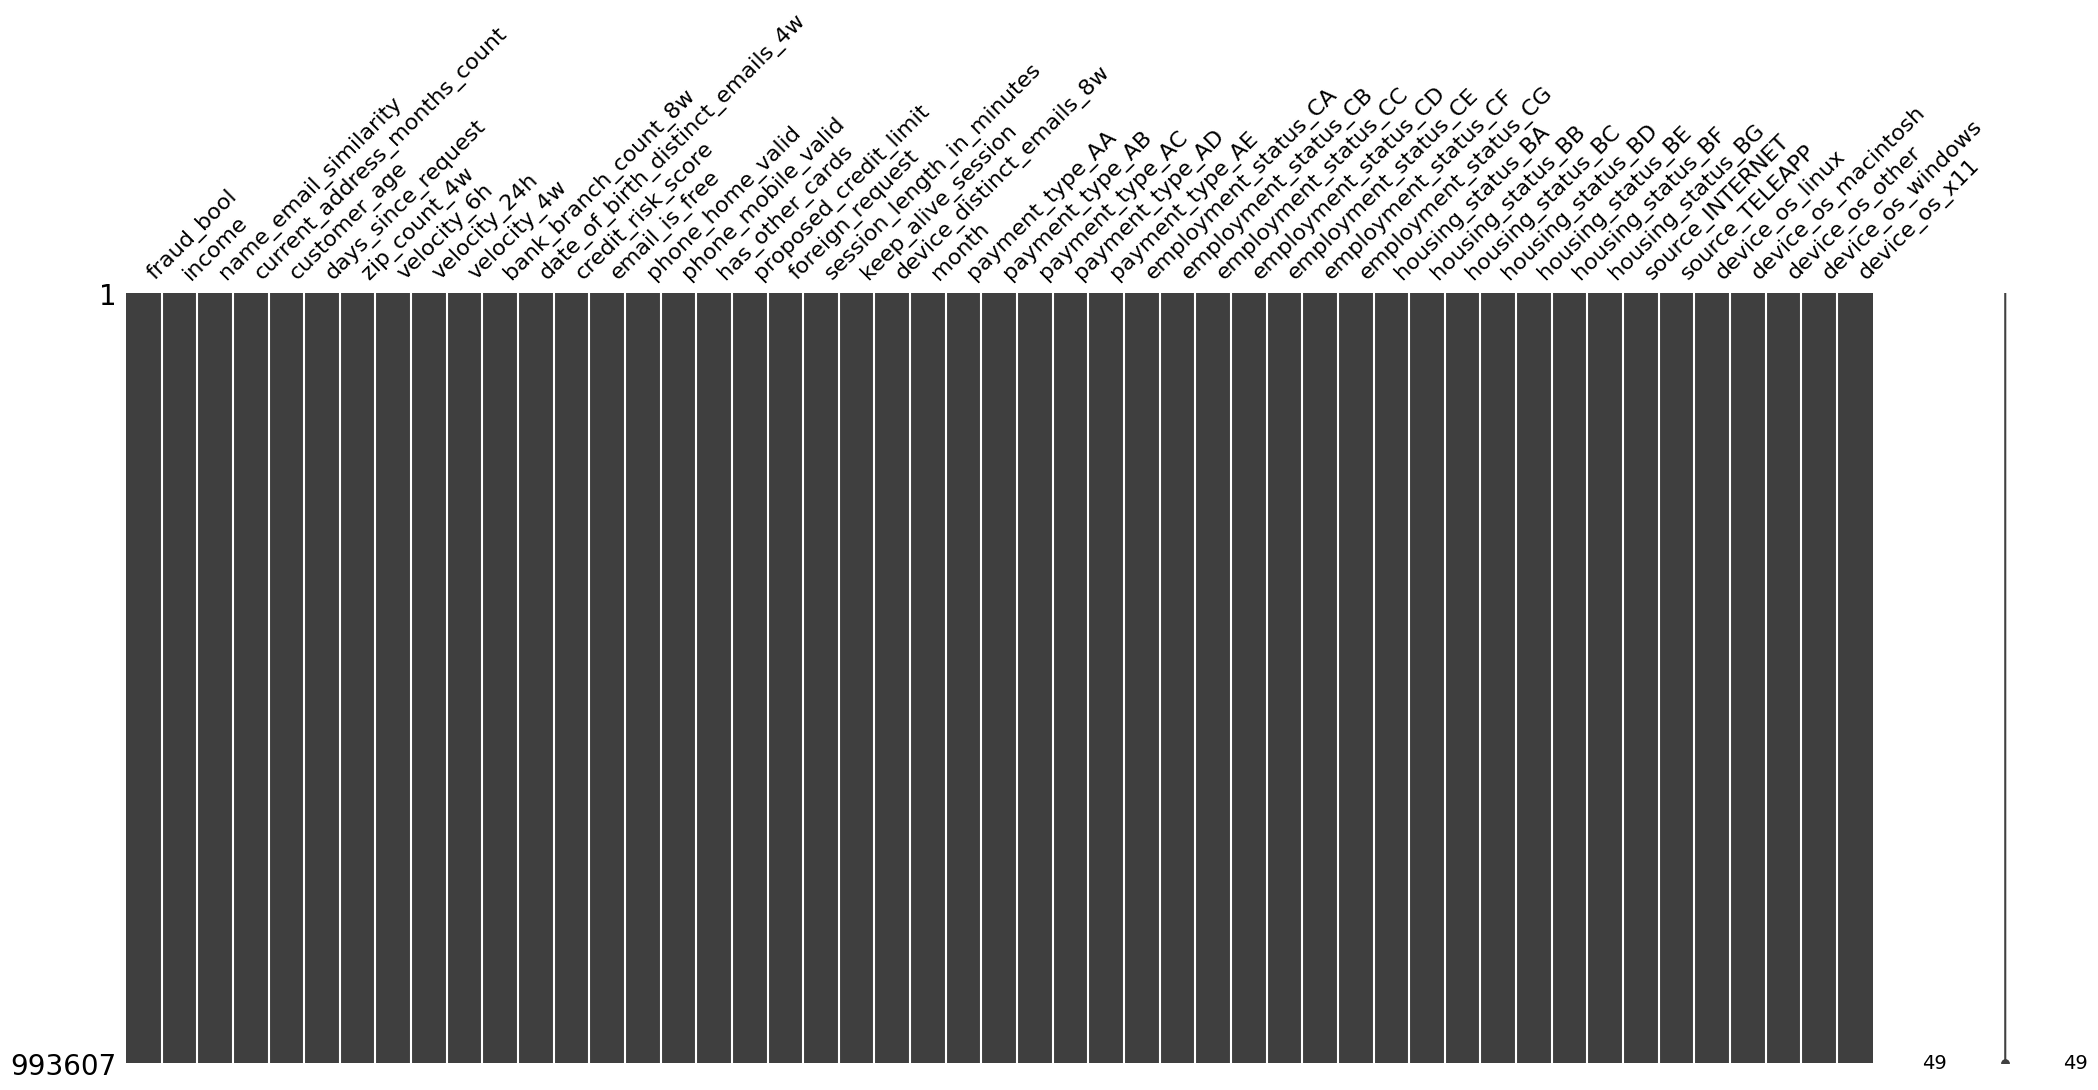

In [28]:
missingno.matrix(df)
plt.show()

In [29]:
### fraud

df.fraud_bool.value_counts()

# label로 활용될 변수
# 사기 X -> 988971
# 사기 O -> 11029

# imbalanced data
# 100만건 중 11029건의 데이터만 사기 계좌
### 분석에 시작하기 전에 sampling을 다시 해줘야한다.

fraud_bool
0    982612
1     10995
Name: count, dtype: int64

In [30]:
df.to_csv('data/step1.csv', index = False)

## 이상치 제거

In [31]:
df_numeric.columns

Index(['income', 'name_email_similarity', 'prev_address_months_count',
       'current_address_months_count', 'customer_age', 'days_since_request',
       'intended_balcon_amount', 'zip_count_4w', 'velocity_6h', 'velocity_24h',
       'velocity_4w', 'bank_branch_count_8w',
       'date_of_birth_distinct_emails_4w', 'credit_risk_score',
       'bank_months_count', 'proposed_credit_limit',
       'session_length_in_minutes', 'month'],
      dtype='object')

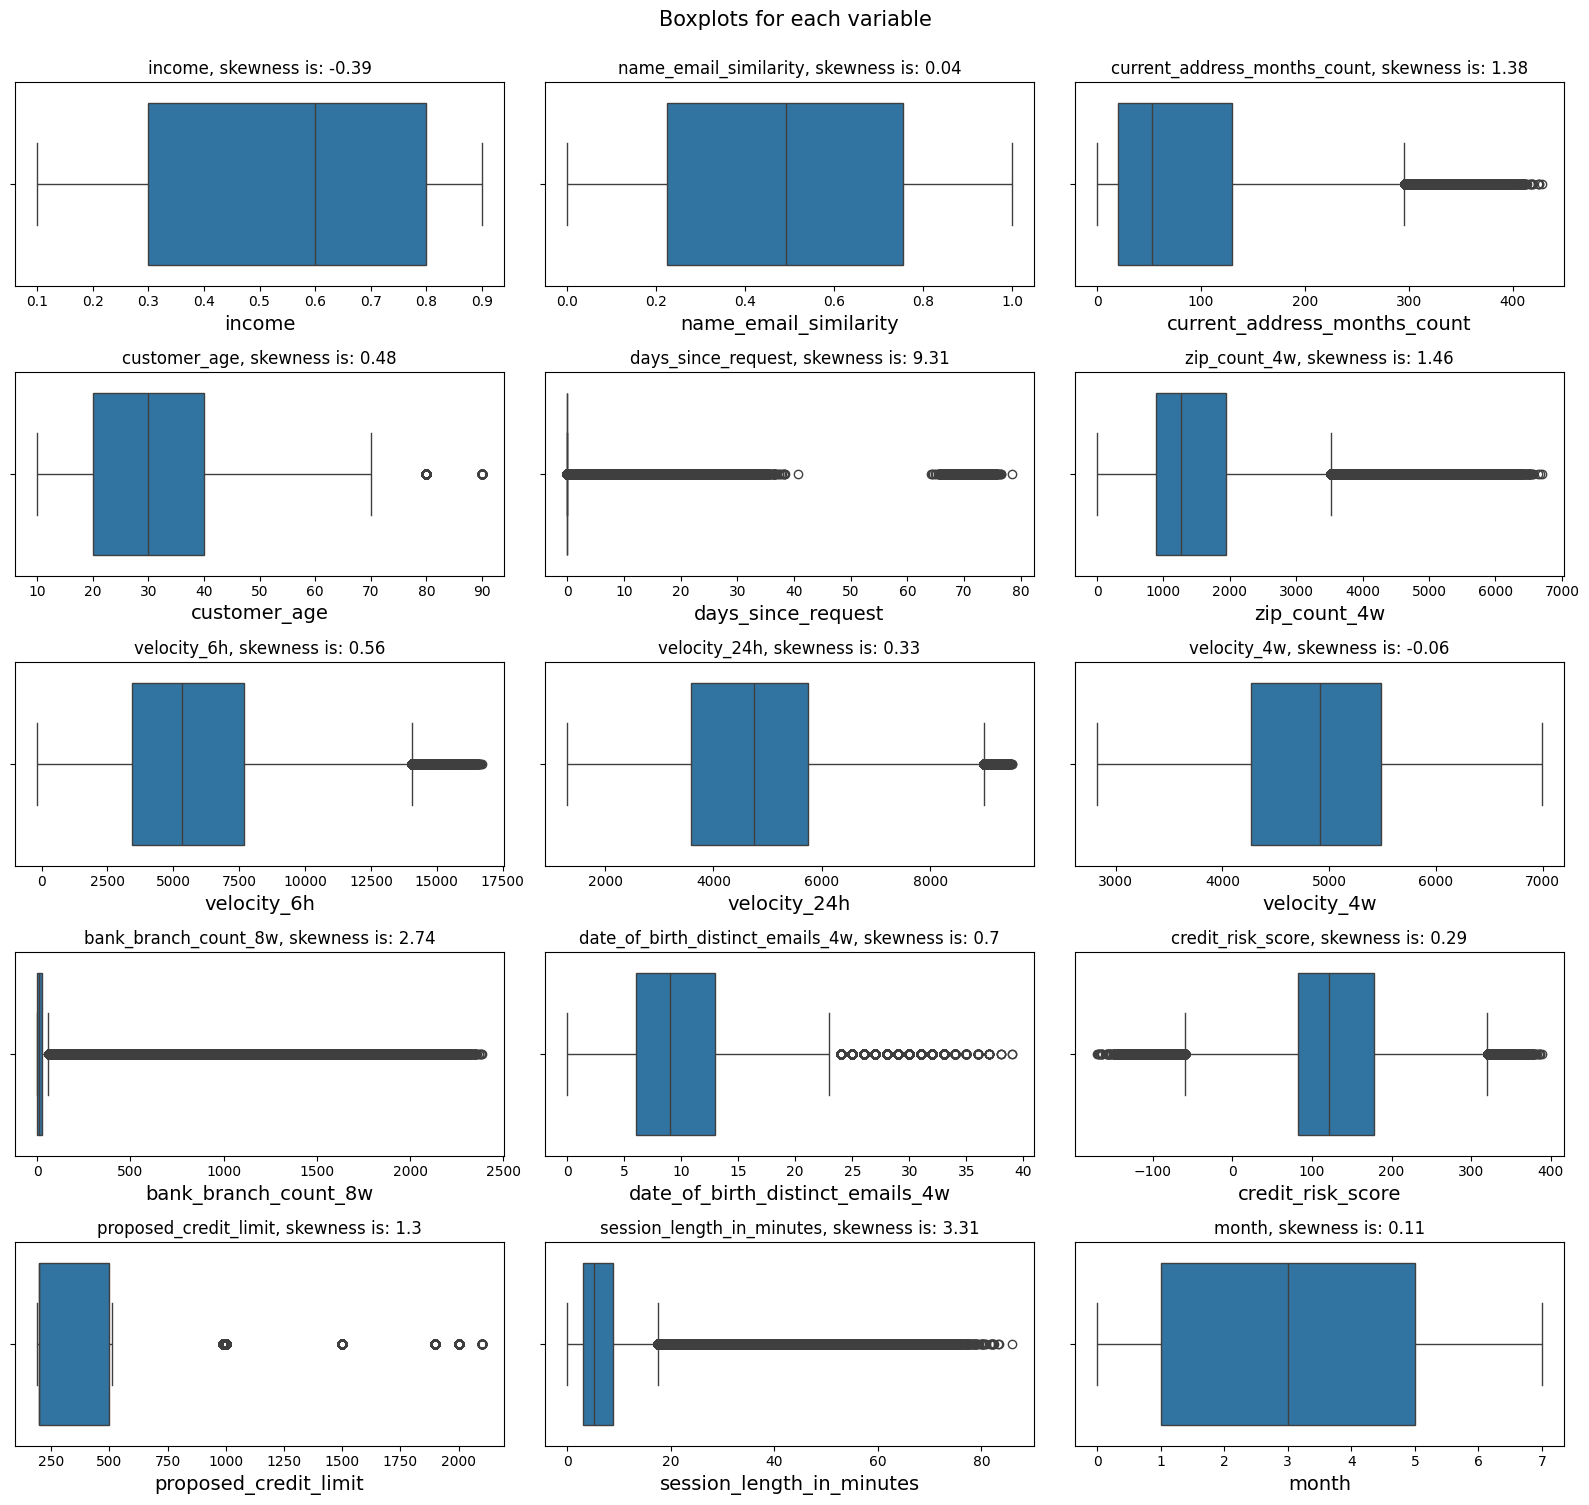

In [32]:
numeric_columns = df_numeric.columns
numeric_columns = numeric_columns.drop(['prev_address_months_count', 'intended_balcon_amount', 'bank_months_count'])

# checking boxplots
def boxplots_custom(dataset, columns_list, rows, cols, suptitle):
    fig, axs = plt.subplots(rows, cols, sharey=True, figsize=(16,15))
    fig.suptitle(suptitle,y=1, size=15)
    axs = axs.flatten()
    for i, data in enumerate(columns_list):
        sns.boxplot(data=dataset[data], orient='h', ax=axs[i])
        axs[i].set_title(data + ', skewness is: '+str(round(dataset[data].skew(axis = 0, skipna = True),2)))
        
boxplots_custom(dataset=df, columns_list=numeric_columns, rows=5, cols=3, suptitle='Boxplots for each variable')
plt.tight_layout()

plt.savefig('image/boxplot.png')


In [33]:
def IQR_method (df,n,features):
    """
    Takes a dataframe and returns an index list corresponding to the observations 
    containing more than n outliers according to the Tukey IQR method.
    """
    outlier_list = []
    
    for column in features:
        # 1st quartile (25%)
        Q1 = np.percentile(df[column], 25)
        # 3rd quartile (75%)
        Q3 = np.percentile(df[column], 75)
        # Interquartile range (IQR)
        IQR = Q3 - Q1
        # outlier step
        outlier_step = 1.5 * IQR
        # Determining a list of indices of outliers
        outlier_list_column = df[(df[column] < Q1 - outlier_step) | (df[column] > Q3 + outlier_step )].index
        # appending the list of outliers 
        outlier_list.extend(outlier_list_column)
        
    # selecting observations containing more than x outliers
    outlier_list = Counter(outlier_list)        
    multiple_outliers = list( k for k, v in outlier_list.items() if v > n )
    
    # Calculate the number of records below and above lower and above bound value respectively
    out1 = df[df[column] < Q1 - outlier_step]
    out2 = df[df[column] > Q3 + outlier_step]
    
    print('Total number of deleted outliers is:', out1.shape[0]+out2.shape[0])
    
    return multiple_outliers

In [34]:
def count_outlier(df, features):
        
    for column in features:
    
        outlier_list = []

        # 1st quartile (25%)
        Q1 = np.percentile(df[column], 25)
        # 3rd quartile (75%)
        Q3 = np.percentile(df[column], 75)
        # Interquartile range (IQR)
        IQR = Q3 - Q1
        # outlier step
        outlier_step = 1.5 * IQR
        # Determining a list of indices of outliers
        outlier_list_column = df[(df[column] < Q1 - outlier_step) | (df[column] > Q3 + outlier_step )].index
        # appending the list of outliers 
        outlier_list.extend(outlier_list_column)

        print(column, len(outlier_list))

In [35]:
count_outlier(df, numeric_columns)

income 0
name_email_similarity 0
current_address_months_count 41389
customer_age 1357
days_since_request 93307
zip_count_4w 59538
velocity_6h 8947
velocity_24h 2937
velocity_4w 0
bank_branch_count_8w 174496
date_of_birth_distinct_emails_4w 9674
credit_risk_score 8703
proposed_credit_limit 240575
session_length_in_minutes 78486
month 0


## outlier가 존재하는 column

- current_address_months_count(현재주소 거주기간) 41389
- customer_age(고객나이) 1357
- days_since_request(계좌생성이 완료된 후 경과일수) 93307
- zip_count_4w(해당 우편번호에서 계좌가 생성된수) 59538
- velocity_6h(지난 6시간동안 이루어진 number of application ) 8947
- velocity_24h(지난 24시간동안 이루어진 number of application ) 2937
- bank_branch_count_8w(8주동안 해당 은행에서 개설된 계좌수) 174496
- date_of_birth_distinct_emails_4w(지난 4주 동안 같은 생년월일이 계좌를 개설한 수) 9674
- credit_risk_score(은행 신용점수) 8703
- proposed_credit_limit(신용카드 한도) 240575
- session_length_in_minutes(웹사이트에서 머문 시간) 78486


In [36]:
def delete_outlier(df, features):
        
    for column in features:
    
        outlier_list = []

        # 1st quartile (25%)
        Q1 = np.percentile(df[column], 25)
        # 3rd quartile (75%)
        Q3 = np.percentile(df[column], 75)
        # Interquartile range (IQR)
        IQR = Q3 - Q1
        # outlier step
        outlier_step = 1.5 * IQR
        # Determining a list of indices of outliers
        outlier_list_column = df[(df[column] < Q1 - outlier_step) | (df[column] > Q3 + outlier_step )].index
        # appending the list of outliers 
        outlier_list.extend(outlier_list_column)

        # Remove duplicates in the outlier_list
        outlier_list = list(set(outlier_list))

        # Drop outliers
        df.drop(outlier_list, inplace=True)

In [37]:
## 계좌 사기와 관련되지 않은 feature만 outlier 제거

outlier_columns = ['session_length_in_minutes']
df_out = df.copy()
delete_outlier(df_out, outlier_columns)

In [38]:
df_out.shape, df.shape

((915121, 49), (993607, 49))

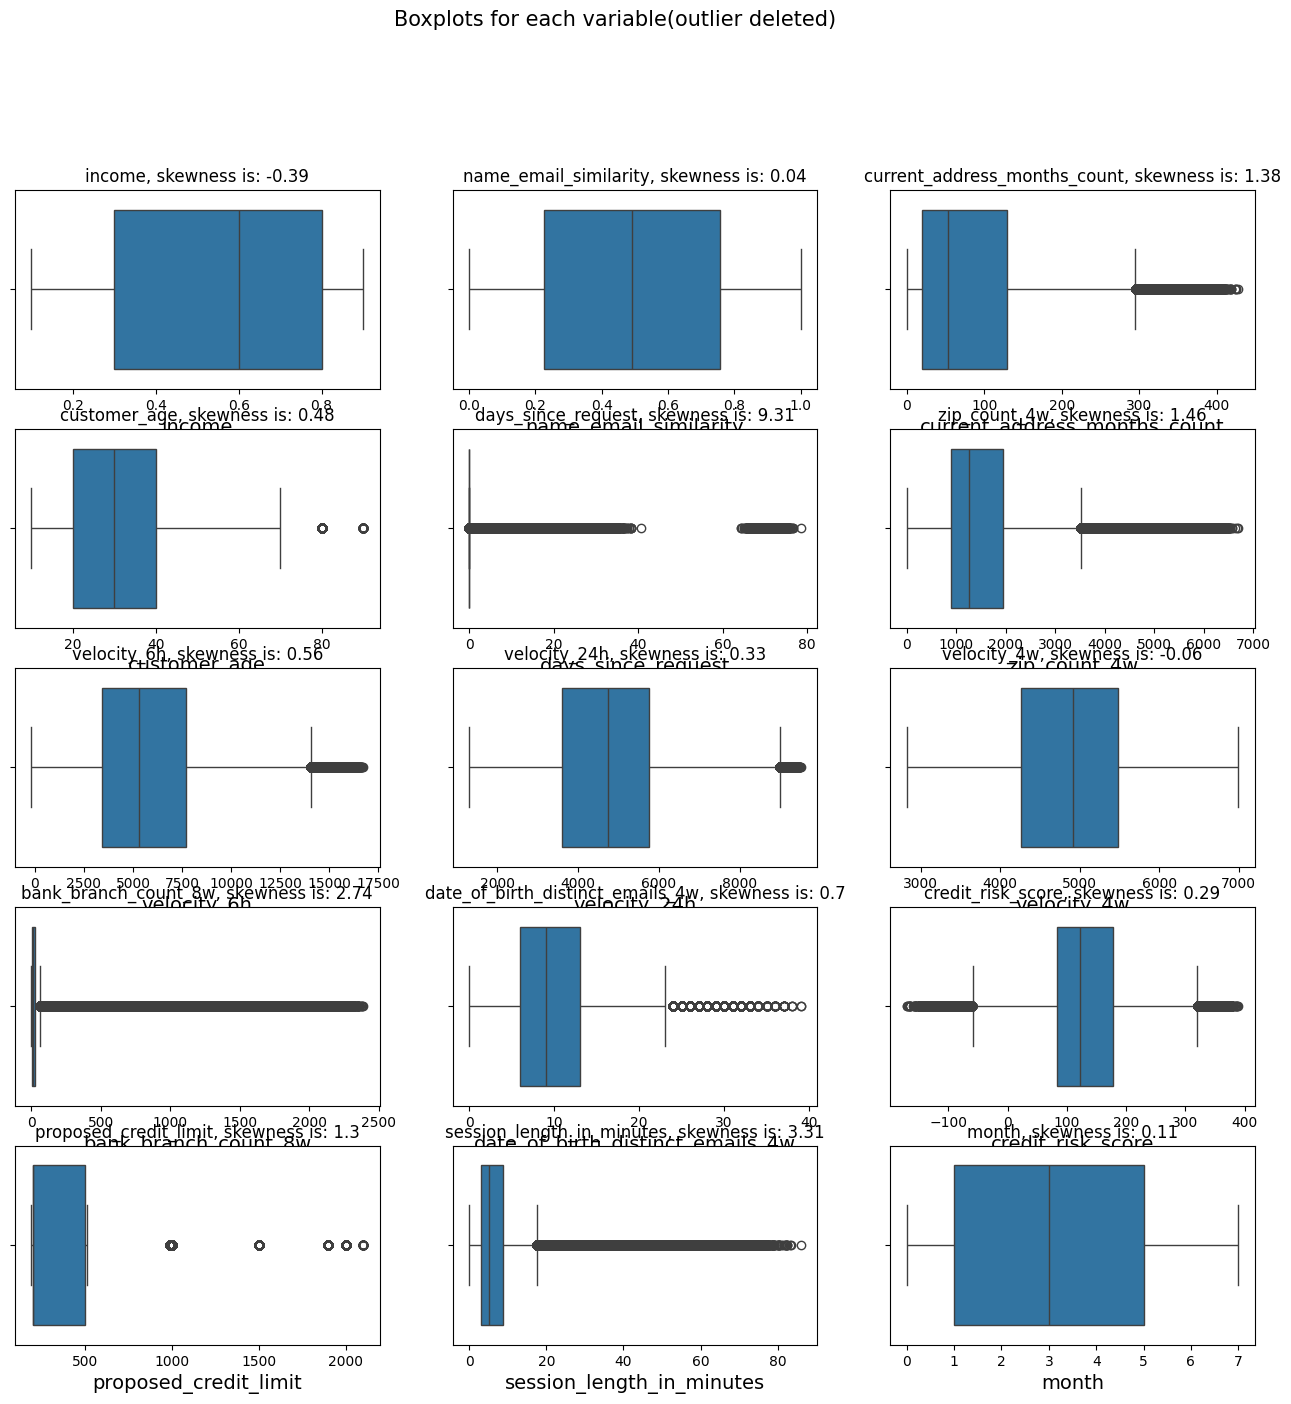

In [39]:
boxplots_custom(dataset=df, columns_list=numeric_columns, rows=5, cols=3, suptitle='Boxplots for each variable(outlier deleted)')

### SMOTE

In [40]:
X = df_out.drop(columns='fraud_bool')
y = df_out['fraud_bool']


from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, shuffle=True, random_state=1)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((640584, 48), (274537, 48), (640584,), (274537,))

In [41]:
from imblearn.over_sampling import SMOTE
sm = SMOTE()
X_resampled, y_resampled = sm.fit_resample(X_train, y_train)

In [42]:
X_resampled.shape, len(y_resampled)

((1267372, 48), 1267372)

In [43]:
y_resampled.value_counts()

fraud_bool
0    633686
1    633686
Name: count, dtype: int64

In [44]:
y_test.value_counts()

fraud_bool
0    271581
1      2956
Name: count, dtype: int64

In [45]:
y_train.value_counts()

fraud_bool
0    633686
1      6898
Name: count, dtype: int64

In [46]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

In [47]:
lr_pipe = Pipeline([('scaler', StandardScaler()),
               ('lr', LogisticRegression( C= 20, max_iter= 1000))])

lr_pipe.fit(X_resampled, y_resampled)
lr_pipe.score(X_resampled, y_resampled)

0.9837080194291811

In [48]:
lr_pipe.score(X_test, y_test)

0.9810335218932239

In [49]:
from xgboost import XGBClassifier

In [50]:
xgb = XGBClassifier()

In [51]:
xgb.fit(X_resampled, y_resampled)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [52]:
xgb.score(X_resampled, y_resampled)

0.9940617277326625

In [54]:
xgb.score(X_test, y_test)

0.9883039444592168

In [55]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, max_features=16, 
                                  random_state=1)
rf_model.fit(X_resampled, y_resampled)

RandomForestClassifier(max_features=16, random_state=1)

In [56]:
rf_model.score(X_resampled, y_resampled)

0.9999968438627332

In [57]:
rf_model.score(X_test, y_test)

0.988438716821412

In [58]:
rf_model.score(X_train, y_train)

0.9999937556979256

In [59]:
from imblearn.under_sampling import RandomUnderSampler
X_under, y_under = RandomUnderSampler(random_state=2021).fit_resample(X_train, y_train)

In [60]:
X_under.shape, y_under.shape, y_under.value_counts()

((13796, 48),
 (13796,),
 fraud_bool
 0    6898
 1    6898
 Name: count, dtype: int64)

In [61]:
lr_under = Pipeline([('scaler', StandardScaler()),
               ('lr', LogisticRegression( C= 20, max_iter= 1000))])

lr_under.fit(X_under, y_under)
lr_under.score(X_under, y_under)

0.7955204407074514

In [62]:
lr_under.score(X_test, y_test)

0.800332924159585

In [ ]:
xgb = XGBClassifier()

In [63]:
xgb.fit(X_under, y_under)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [67]:
xgb.score(X_under, y_under)

0.9644099739054799

In [66]:
xgb.score(X_train, y_train)

0.8042473742709777

In [65]:
xgb.score(X_test, y_test)

0.799826617177284

In [68]:
y_train.value_counts()

fraud_bool
0    633686
1      6898
Name: count, dtype: int64

In [69]:
y_resampled.value_counts()

fraud_bool
0    633686
1    633686
Name: count, dtype: int64